## Reading the data

In [1]:
import pandas as pd
from pathlib import Path
import re
import json
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

models_names = [
    "Deepseek",
    "Falcon3",
    "Llama",
    "Mistral",
    "Phi3",
    "Qwen",
]

results_path = Path("llm_results_public")

def load_results(model_name: str) -> pd.DataFrame:
    file_path = results_path / f"PANDEIA_RESULTS_{model_name}_fewshot.csv"
    return pd.read_csv(file_path)

def clean_result_dataset(df):
    return df[["ID", "Subreddit", "subthemes_oneshot", "polarization_oneshot", "subthemes_zeroshot", "polarization_zeroshot", "subthemes_fewshot", "polarization_fewshot"]]

manual_labeling_dataset_path = results_path / "PANDEIA_DATASET_ManualLabeling_Final.csv"

manual_labeling_dataset = pd.read_csv(manual_labeling_dataset_path)

manual_labeling_dataset["Agreement_Polarization"] = manual_labeling_dataset["Agreement_Polarization"].fillna("Neutral") # casos de disacordo entre os rotuladores

datasets = {}

for i in range(len(models_names)):
    datasets[models_names[i]] = clean_result_dataset(load_results(models_names[i]))

In [2]:
for dataset_name, dataset in datasets.items():
    print("# null values in", dataset_name)
    nulls = dataset.isnull().sum().to_frame()
    nulls['%'] = dataset.isnull().sum() / len(dataset)
    display(nulls)
    # print(dataset.isnull().sum())


# null values in Deepseek


,0,%
ID,0,0.0
Subreddit,0,0.0
subthemes_oneshot,0,0.0
polarization_oneshot,0,0.0
subthemes_zeroshot,0,0.0
polarization_zeroshot,0,0.0
subthemes_fewshot,0,0.0
polarization_fewshot,0,0.0


# null values in Falcon3


,0,%
ID,0,0.0
Subreddit,0,0.0
subthemes_oneshot,0,0.0
polarization_oneshot,0,0.0
subthemes_zeroshot,0,0.0
polarization_zeroshot,0,0.0
subthemes_fewshot,0,0.0
polarization_fewshot,0,0.0


# null values in Llama


...

,0,%
ID,0,0.0
Subreddit,0,0.0
subthemes_oneshot,0,0.0
polarization_oneshot,0,0.0
subthemes_zeroshot,0,0.0
polarization_zeroshot,0,0.0
subthemes_fewshot,0,0.0
polarization_fewshot,0,0.0


# null values in Phi3


,0,%
ID,0,0.0
Subreddit,0,0.0
subthemes_oneshot,0,0.0
polarization_oneshot,0,0.0
subthemes_zeroshot,0,0.0
polarization_zeroshot,0,0.0
subthemes_fewshot,0,0.0
polarization_fewshot,0,0.0


# null values in Qwen


,0,%
ID,0,0.0
Subreddit,0,0.0
subthemes_oneshot,0,0.0
polarization_oneshot,0,0.0
subthemes_zeroshot,0,0.0
polarization_zeroshot,0,0.0
subthemes_fewshot,0,0.0
polarization_fewshot,0,0.0


In [3]:
datasets["Deepseek"].head()

,ID,Subreddit,subthemes_oneshot,polarization_oneshot,subthemes_zeroshot,polarization_zeroshot,subthemes_fewshot,polarization_fewshot
0,16iasg,girlsgonewired,"{\n ""subtheme"": {\n ""gender"": 1,\n ""rac...","{\n\n ""polarization"": ""anti-DEIA"",\n ""justif...","{\n ""subtheme"": {\n ""gender"": 0,\n ""rac...","{\n ""polarization"": ""anti-DEIA"",\n ""justific...","{\n ""subtheme"": {\n ""gender"": 1,\n ""rac...","{\n ""polarization"": ""anti-DEIA"",\n ""justific..."
1,1kyq4q,girlsgonewired,"{\n\n ""subtheme"": {\n ""gender"": 1,\n ""r...","{\n ""polarization"": ""pro-DEIA"",\n ""justifica...","{\n ""subtheme"": {\n ""gender"": 1,\n ""rac...","{\n ""polarization"": ""pro-DEIA"",\n ""justifica...","{\n ""subtheme"": {\n ""gender"": 1,\n ""rac...","{\n ""polarization"": ""pro-DEIA"",\n ""justifica..."
2,1xji46,girlsgonewired,"{\n\n""subtheme"": {\n ""gender"": 1,\n ""rac...","{\n ""polarization"": ""pro-DEIA"",\n ""justifica...","{\n\n ""subtheme"": {\n ""gender"": 1,\n ""r...","{\n\n""polarization"": ""pro-DEIA"", ""justificatio...","{\n ""subtheme"": {\n ""gender"": 1,\n ""rac...","{\n ""polarization"": ""pro-DEIA"",\n ""justifica..."
3,f3l0fd,cscareerquestions,"{\n\n ""subtheme"": {\n ""gender"": 1,\n ""r...","{\n ""polarization"": ""anti-DEIA"",\n ""justific...","{\n\n""subtheme"": {\n ""gender"": 1,\n ""rac...","{\n ""polarization"": ""neutral"",\n ""justificat...","{\n\n""subtheme"": {""gender"":0,""race"":0,""lgbtq+""...","{\n ""polarization"": ""neutral"",\n ""justificat..."
4,21jvbz,girlsgonewired,"{\n\n""subtheme"": {\n ""gender"": 1,\n ""race"": ...","{\n ""polarization"": ""neutral"",\n ""justificat...","{\n ""subtheme"": {\n ""gender"": 1,\n ""rac...","{\n ""polarization"": ""neutral"",\n ""justificat...","{\n ""subtheme"": {\n ""gender"": 0,\n ""rac...","{\n\n""polarization"": ""anti-DEIA"",\n""justificat..."


In [4]:
manual_labeling_dataset["Agreement_Subthemes"].unique()

<StringArray>
[                          'gender',                             'race',
                     'gender, race',               'disability, gender',
                             'none', 'disability, gender, lgbtq+, race',
             'gender, lgbtq+, race',                   'gender, lgbtq+',
                       'disability',                 'disability, race',
                           'lgbtq+',                     'lgbtq+, race',
       'disability, gender, lgbtq+',               'disability, lgbtq+',
         'disability, gender, race']
Length: 15, dtype: str

##

#### EDA

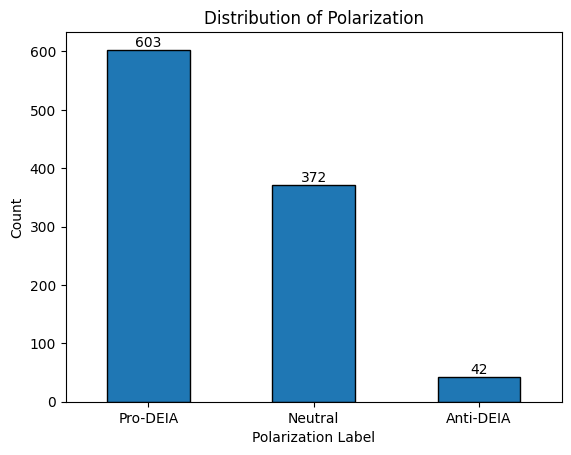

In [5]:
bar = manual_labeling_dataset.Agreement_Polarization.value_counts().plot(kind="bar",
                                                                          title="Distribution of Polarization",
                                                                          xlabel="Polarization Label",
                                                                          ylabel="Count",
                                                                          edgecolor="black")
plt.xticks(rotation=0)
bar.bar_label(bar.containers[0]);

## Looking for problematic lines

In [6]:
VALID_CLASSES = {"pro-DEIA", "anti-DEIA", "neutral"}

mapping = {
    "pro-DEIA": "Pro-DEIA",
    "anti-DEIA": "Anti-DEIA",
    "neutral": "Neutral"
}

In [7]:
def normalize_polarization(value):

    if not value:
        return "None"

    value = value.strip()

    if value in VALID_CLASSES:
        return mapping[value]

    return "None"

def polarization_parsing_eda(df, column_name):

    records = []

    for idx, row in df.iterrows():

        diagnosis = diagnose_json(row[column_name])

        polarization_norm = normalize_polarization(
            diagnosis["polarization"]
        )

        record = {
            "row_id": idx,
            "valid_json": diagnosis["valid_json"],
            "error_type": diagnosis["error_type"],
            "error_message": diagnosis["error_message"],
            "polarization_raw": diagnosis["polarization"],
            "polarization_normalized": polarization_norm,
            "raw_preview": diagnosis["raw_preview"]
        }

        records.append(record)

    return pd.DataFrame(records)

def diagnose_json(text: str):
    """
    Try to extract JSON from the given text and parse the "polarization" field.
    """

    result = {
        "polarization": None,
        "valid_json": False,
        "error_type": None,
        "error_message": None,
        "raw_preview": str(text)[:200]
    }

    if not text or not isinstance(text, str):
        result["error_type"] = "non_string"
        return result

    # remove markdown
    text = re.sub(r"```json|```", "", text)

    start = text.find("{")
    if start == -1:
        result["error_type"] = "no_json_found"
        return result

    brace_count = 0
    json_str = None

    for i in range(start, len(text)):
        if text[i] == "{":
            brace_count += 1
        elif text[i] == "}":
            brace_count -= 1

        if brace_count == 0:
            json_str = text[start:i+1]
            break

    if json_str is None:
        result["error_type"] = "unbalanced_braces"
        return result

    try:
        parsed = json.loads(json_str)

        result["valid_json"] = True
        result["polarization"] = parsed.get("polarization", None)

    except json.JSONDecodeError as e:

        result["error_type"] = "json_decode_error"
        result["error_message"] = str(e)

    return result

In [8]:
eda_df = polarization_parsing_eda(
    datasets["Deepseek"],
    "polarization_oneshot"
)

In [9]:
eda_df["error_type"].value_counts()

Series([], Name: count, dtype: int64)

In [10]:
eda_df["valid_json"].value_counts()

valid_json
True    1017
Name: count, dtype: int64

In [11]:
eda_df[eda_df["valid_json"] == False].head(10)

,row_id,valid_json,error_type,error_message,polarization_raw,polarization_normalized,raw_preview


### Processing the output JSON

In [12]:
def extract_first_json(text: str):
    if not text or type(text) != str:
        return {"polarization": "JSON Inválido"}
    # remove markdown
    text = re.sub(r"```json|```", "", text)

    start = text.find("{")
    if start == -1:
        return {"polarization": "JSON Inválido"}

    brace_count = 0

    for i in range(start, len(text)):
        if text[i] == "{":
            brace_count += 1
        elif text[i] == "}":
            brace_count -= 1

        if brace_count == 0:
            json_str = text[start:i+1]
            break
    else:
        return {"polarization": "JSON Inválido"}

    # tentativa de parse
    try:
        return json.loads(json_str)
    except json.JSONDecodeError:
        # correções comuns
        return {"polarization": "JSON Inválido"}

def extract_polarization_pipeline(df, column_name):
    """
    Complete pipeline:
    1. Extract JSON from LLM output
    2. Get the polarization field
    3. Normalize the class
    """

    results = []

    for _, row in df.iterrows():

        parsed = extract_first_json(row[column_name])

        polarization = parsed.get("polarization", None)

        polarization = normalize_polarization(polarization)

        results.append(polarization)

    return results

In [13]:
from pathlib import Path
import pandas as pd

def collect_problematic_indices(datasets, models_names, column_name, output_dir):
    """
    For each model:
    - detects invalid JSON
    - saves indices of problematic rows
    - saves CSV with these indices
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    problems_by_model = {}

    for model in models_names:

        df = datasets[model]

        problematic_indices = []

        for idx, row in df.iterrows():

            diagnosis = diagnose_json(row[column_name])

            if not diagnosis["valid_json"]:
                problematic_indices.append(row['ID'])

        problems_by_model[model] = problematic_indices

        # salva CSV para auditoria
        pd.DataFrame({
            "row_index": problematic_indices
        }).to_csv(
            output_dir / f"{model}_problematic_rows.csv",
            index=False
        )

    return problems_by_model

print('zeroshot', collect_problematic_indices(
    datasets,
    models_names,
    "polarization_zeroshot",
    "results/json_problems/json_problems_zeroshot"
))

print('oneshot', collect_problematic_indices(
    datasets,
    models_names,
    "polarization_oneshot",
    "results/json_problems/json_problems_oneshot"
))

print('fewshot', collect_problematic_indices(
    datasets,
    models_names,
    "polarization_fewshot",
    "results/json_problems/json_problems_fewshot"
))

zeroshot {'Deepseek': [], 'Falcon3': ['rcsusp', 'qoltod'], 'Llama': ['u9xfyf'], 'Mistral': ['2wrxif'], 'Phi3': [], 'Qwen': []}
oneshot {'Deepseek': [], 'Falcon3': [], 'Llama': [], 'Mistral': [], 'Phi3': [], 'Qwen': []}
fewshot {'Deepseek': [], 'Falcon3': [], 'Llama': [], 'Mistral': ['dn1icd'], 'Phi3': [], 'Qwen': []}


In [14]:
manual_labeling_dataset[manual_labeling_dataset['ID'] == 'dn1icd']

,ID,Date,Subreddit,Permalink,Score,num_comment,DEIA?_x,KeyWords_x,SubTheme_x,Position_x,...,Justification_x,DEIA?_y,KeyWords_y,SubTheme_y,Position_y,Confidence level_y,Justification_y,IS_DEIA?,Agreement_Polarization,Agreement_Subthemes
126,dn1icd,2019-10-25 18:22:25 UTC,technology,https://www.reddit.com/r/technology/comments/d...,43,11,no,"climate change mitigation, deforestation, refo...",NaN,Neutral,...,O texto é complexo e grande sobre um post info...,no,"Deforestation, climate mitigation, forest moni...",LGBTQIA+,Pro-DEIA,5.0,The text centers on environmental technologies...,no,Pro-DEIA,lgbtq+


In [15]:
manual_labeling_dataset[manual_labeling_dataset['ID'].isin(['rcsusp', 'qoltod', '2wrxif', 'u9xfyf'])]

,ID,Date,Subreddit,Permalink,Score,num_comment,DEIA?_x,KeyWords_x,SubTheme_x,Position_x,...,Justification_x,DEIA?_y,KeyWords_y,SubTheme_y,Position_y,Confidence level_y,Justification_y,IS_DEIA?,Agreement_Polarization,Agreement_Subthemes
256,2wrxif,2022-02-28 05:02:01 UTC,cscareerquestions,https://www.reddit.com/r/cscareerquestions/com...,1220,150,no,NaN,LGBTQIA+,Pro-DEIA,...,Conselhos sobre como achar boas oportunidades ...,no,mental health,NaN,Neutral,2.0,"O texto é uma narrativa pessoal de carreira, e...",no,Pro-DEIA,lgbtq+
266,u9xfyf,2022-04-23 04:37:26 UTC,ExperiencedDevs,https://www.reddit.com/r/ExperiencedDevs/comme...,58,21,no,"manage, advise, architecture, career progresses",NaN,Neutral,...,insegurança profissional após mudar de emprego,no,"career struggle, software development, custome...",NaN,Neutral,5.0,The text describes a developer’s career trajec...,no,Neutral,none
336,rcsusp,2023-04-15 11:29:15 UTC,cscareerquestions,https://www.reddit.com/r/cscareerquestions/com...,538,565,no,NaN,NaN,Neutral,...,Dúvida de usuário sobre título de trabalho par...,no,"engineer, software developer, software enginee...",NaN,Neutral,5.0,O texto fala apenas sobre a terminologia profi...,no,Neutral,none
675,qoltod,2025-02-13 00:37:54 UTC,cscareerquestions,https://www.reddit.com/r/cscareerquestions/com...,23,59,no,psych degree,NaN,Neutral,...,The author expresses disappointment about care...,no,NaN,NaN,Neutral,5.0,Não consegui perceber nada relacionado ao DEIA,no,Neutral,none


In [16]:
print("Polarization Zeroshot:")
for dataset_name, dataset in datasets.items():
    print(dataset_name, extract_polarization_pipeline(dataset, 'polarization_zeroshot').count("None"))

print()

print("Polarization Oneshot:")
for dataset_name, dataset in datasets.items():
    print(dataset_name, extract_polarization_pipeline(dataset, 'polarization_oneshot').count("None"))

print()

print("Polarization Fewshot:")
for dataset_name, dataset in datasets.items():
    print(dataset_name, extract_polarization_pipeline(dataset, 'polarization_fewshot').count("None"))

Polarization Zeroshot:
Deepseek 0
Falcon3 2
Llama 1
Mistral 1
Phi3 0
Qwen 0

Polarization Oneshot:
Deepseek 0
Falcon3 0
Llama 0
Mistral 0
Phi3 0
Qwen 0

Polarization Fewshot:
Deepseek 0
Falcon3 0
Llama 0
Mistral 1
Phi3 0
Qwen 0


In [17]:
VALID_CLASSES = {"pro-DEIA", "anti-DEIA", "neutral"}
mapping = {
    "pro-DEIA": "Pro-DEIA",
    "anti-DEIA": "Anti-DEIA",
    "neutral": "Neutral"
}

def normalize_polarization(value):
    """
    Normalizes the polarization field returned by the LLM.
    """
    if not value:
        return "None"

    value = value.strip()

    if value in VALID_CLASSES:
        return mapping[value]

    return "None"

In [18]:
for model_name in models_names:
    datasets[model_name]["polarization_class_zeroshot"] = extract_polarization_pipeline(
            datasets[model_name],
            "polarization_zeroshot"
        )

    datasets[model_name]["polarization_class_oneshot"] = extract_polarization_pipeline(
            datasets[model_name],
            "polarization_oneshot"
        )

    datasets[model_name]["polarization_class_fewshot"] = extract_polarization_pipeline(
            datasets[model_name],
            "polarization_fewshot"
        )

## LLM Evaluation

In [19]:
def evaluate_classification(y_true, y_pred, output_dir):
    """
    Generates classification report, confusion matrix (CSV) 
    and confusion matrix heatmap (PNG).
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    # ------------------------------------------------
    # Classification Report
    # ------------------------------------------------
    report_dict = classification_report(
        y_true,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report_dict).transpose()
    report_path = output_dir / "classification_report.csv"
    report_df.to_csv(report_path)

    # ------------------------------------------------
    # Confusion Matrix
    # ------------------------------------------------
    labels = sorted(list(set(y_true) | set(y_pred)))

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    cm_df = pd.DataFrame(
        cm,
        index=[f"{l}" for l in labels],
        columns=[f"{l}" for l in labels]
    )

    cm_path = output_dir / "confusion_matrix.csv"
    cm_df.to_csv(cm_path)

    # ------------------------------------------------
    # Heatmap
    # ------------------------------------------------
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm_df,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=True
    )

    plt.title("Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")

    heatmap_path = output_dir / "confusion_matrix_heatmap.png"
    plt.tight_layout()
    plt.savefig(heatmap_path, dpi=300)
    plt.close()

    return report_df, cm_df

In [20]:
deia_indexes = manual_labeling_dataset[manual_labeling_dataset['IS_DEIA?'] == 'yes'].index

In [21]:
y_polarization = manual_labeling_dataset.loc[deia_indexes, "Agreement_Polarization"].to_numpy()
y_subthemes = manual_labeling_dataset.loc[deia_indexes, "Agreement_Subthemes"].to_numpy()

In [22]:
polarization_classes = ["Pro-DEIA", "Anti-DEIA", "Neutral"]

def plot_class_distribution(predictions, output_dir, model_name, strategy):

    counts = (
        pd.Series(predictions)
        .value_counts()
        .reindex(polarization_classes, fill_value=0)
    )

    plt.figure()

    bar = counts.plot(kind="bar", edgecolor="black")
    bar.bar_label(bar.containers[0])

    plt.title(f"{model_name} — {strategy}")
    plt.xlabel("Polarization Class")
    plt.ylabel("Count")

    plt.xticks(rotation=0)

    plt.tight_layout()

    output_dir.mkdir(parents=True, exist_ok=True)

    plt.savefig(output_dir / f"class_distribution_{model_name}.png", dpi=300)

    plt.close()

In [23]:
for model_name in models_names:

    preds = datasets[model_name].loc[
        deia_indexes, "polarization_class_zeroshot"
    ].values

    output_dir = Path("results") / "polarization" / "zeroshot" / f"{model_name}_evaluation"

    plot_class_distribution(
        preds,
        output_dir,
        model_name,
        "Zeroshot"
    )

    report, cm = evaluate_classification(
        y_polarization,
        preds,
        output_dir
    )

In [24]:
for model_name in models_names:

    preds = datasets[model_name].loc[
        deia_indexes, "polarization_class_oneshot"
    ].values

    output_dir = Path("results") / "polarization" / "oneshot" / f"{model_name}_evaluation"

    plot_class_distribution(
        preds,
        output_dir,
        model_name,
        "Oneshot"
    )

    report, cm = evaluate_classification(
        y_polarization,
        preds,
        output_dir
    )

In [25]:
for model_name in models_names:

    preds = datasets[model_name].loc[
        deia_indexes, "polarization_class_fewshot"
    ].values

    output_dir = Path("results") / "polarization" / "fewshot" / f"{model_name}_evaluation"

    plot_class_distribution(
        preds,
        output_dir,
        model_name,
        "Fewshot"
    )

    report, cm = evaluate_classification(
        y_polarization,
        preds,
        output_dir
    )